# Domain wall

### import modules

In [1]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'font.size': 16})

import numpy as np
from scipy.optimize import minimize

### Material properties

In [2]:
K  = 410e3             # J/m3 anisotropy constant
A  = 31e-12            # J/m  exchange constant

delta0 = np.sqrt(A/K)  # Bloch parameter

### Computational grid

In [3]:
a = -40.0e-9    # start of region in nm (~ 2 times wall width) 
b =  40.0e-9    # end   of region in nm  
N =  80         # number of cells
L = b-a         # length of region
d = L/N         # cell size  

### Energy

In [4]:
def energy(phi,d,L,K,A):
  phic  = 0.5*(phi[:-1]+phi[1:]) # phi in center of each element
  dphi  = (phi[1:]-phi[:-1])/d   # first derivative (phi[n+1]-phi[n+1])/d
  e_ani = K*(np.sin(phic)**2)    # anisotropy energy density
  e_ex  = A*(dphi*dphi)          # exchange energy density
  e = np.sum( d*(e_ex + e_ani) ) # sum up energy of each cell
  return e          

### minimize energy

In [5]:
phi0 = (N//2)*[np.pi] + (N//2)*[0]              # initial magnetization
phi0 = np.array(phi0)

res  = minimize(energy,phi0,args=(d,L,K,A))
phi  = res.x

### plot

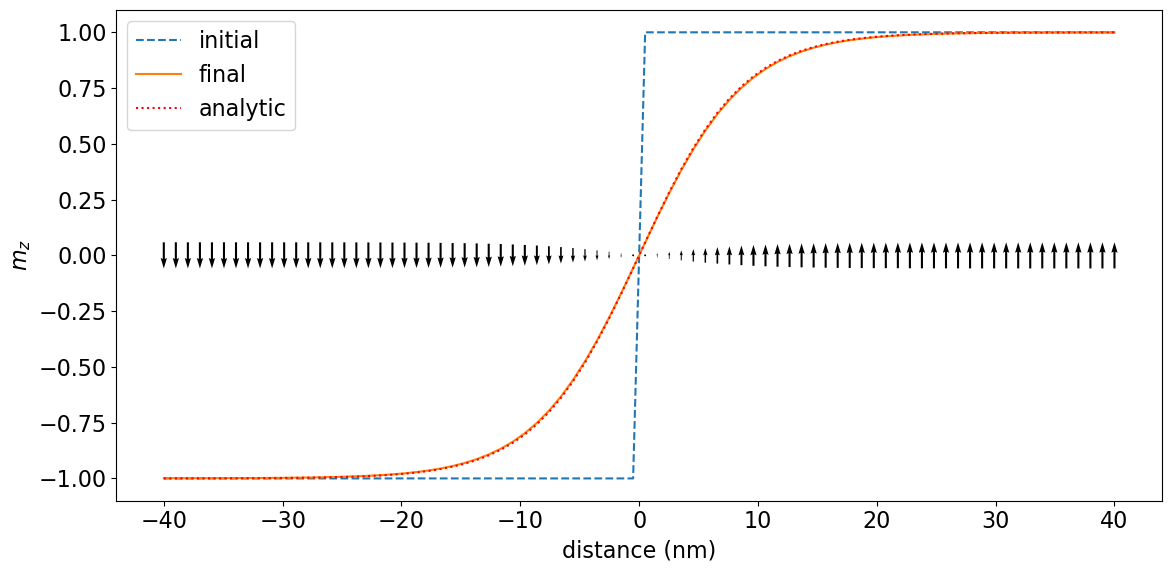

In [6]:
z = np.linspace(a,b,N)           # coordinates of nodes for plotting 
plt.figure(figsize=(12, 6))

plt.plot(z*1e9, np.cos(phi0),    '--',label='initial')
plt.plot(z*1e9, np.cos(phi),          label='final')
plt.plot(z*1e9, np.tanh(z/delta0),':',label='analytic', color='r')

plt.quiver(z*1e9, np.zeros_like(z), 
           np.zeros_like(z), np.cos(phi),           
           scale=40, linewidth=0.05, minshaft=2, width=0.002, pivot='mid')

plt.legend()
plt.xlabel('distance (nm)')
plt.ylabel(r'$m_z$')
plt.tight_layout()
plt.show()